# 📊 Notebook 2: Correlation, Covariance & Hypothesis Testing

In this notebook, we will explore three very important statistical concepts for **Exploratory Data Analysis (EDA)** in Machine Learning & Deep Learning:

1. **Correlation** – how two variables move together (linear or rank-based).
2. **Covariance** – raw measure of how variables vary together.
3. **Hypothesis Testing** – statistical tests to validate insights (Chi-Square, ANOVA, p-value).

We will use **visualizations** and **examples** to deeply understand these ideas.


## 🔗 1. Correlation

**Correlation** measures the *strength and direction* of a relationship between two variables.

- 📈 **Positive correlation**: when one increases, the other increases (e.g., height & weight).
- 📉 **Negative correlation**: when one increases, the other decreases (e.g., exercise & weight).
- 0️⃣ **No correlation**: no clear relationship.

There are two main types:
- **Pearson correlation**: measures *linear* relationships.
- **Spearman correlation**: measures *rank-based* relationships.

Let's see it in practice!


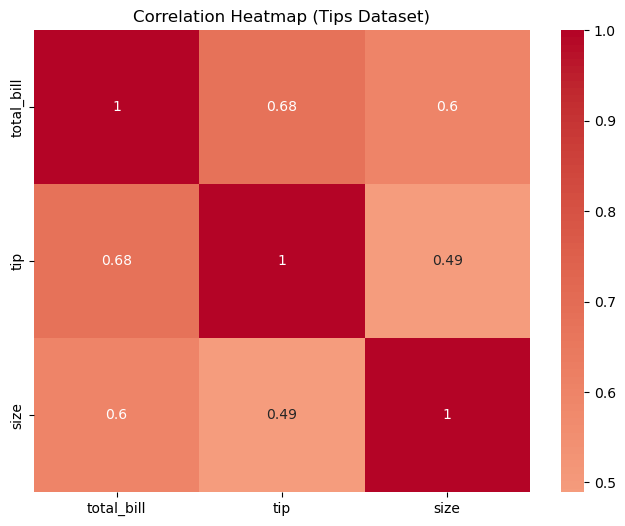

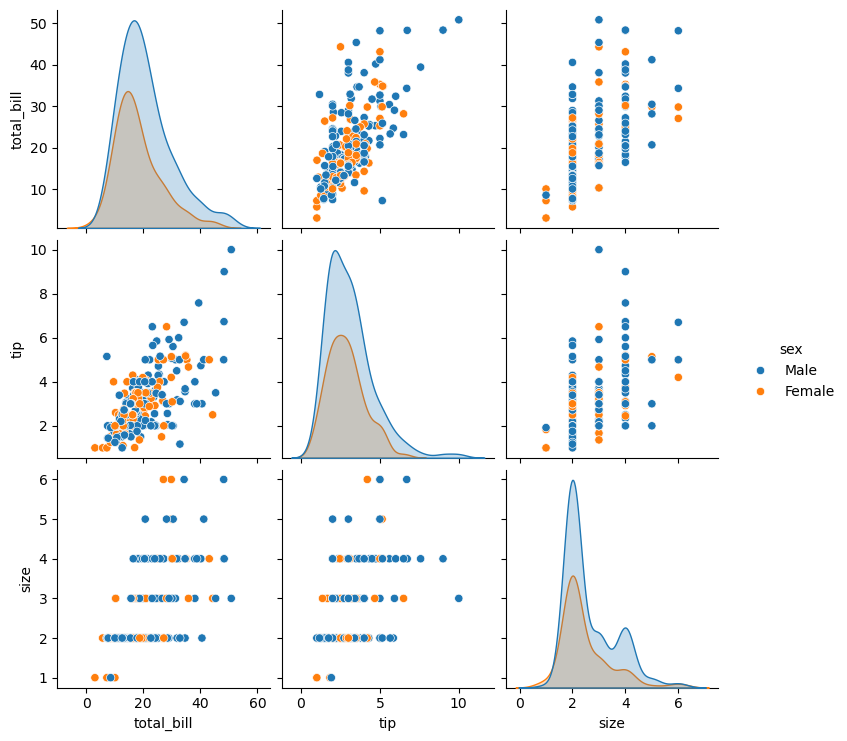

In [1]:

import seaborn as sns
import matplotlib.pyplot as plt

# Load the tips dataset
tips = sns.load_dataset('tips')

# Compute correlation matrix
corr = tips.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Tips Dataset)")
plt.show()

# Pairplot for visual intuition
sns.pairplot(tips, vars=["total_bill", "tip", "size"], hue="sex")
plt.show()


## 📉 2. Covariance

**Covariance** measures how two variables change *together*.

- If both increase together → covariance > 0 (positive)
- If one increases while the other decreases → covariance < 0 (negative)
- If no relationship → covariance ≈ 0

⚠️ The issue: covariance is not standardized (depends on units).  
That’s why **correlation** (normalized version of covariance) is often preferred.


In [2]:

import numpy as np
import pandas as pd

# Example: simple dataset
X = np.array([1, 2, 3, 4, 5])
Y = np.array([2, 4, 6, 8, 10])  # Strong positive relation

cov_matrix = np.cov(X, Y)
print("Covariance Matrix:")
print(cov_matrix)

# Compare with correlation
print("Correlation Coefficient:", np.corrcoef(X, Y)[0,1])


Covariance Matrix:
[[ 2.5  5. ]
 [ 5.  10. ]]
Correlation Coefficient: 0.9999999999999999


## 🧪 3. Hypothesis Testing

In statistics, we test assumptions about populations using **hypothesis tests**.

### p-value (Probability Value)
- Measures evidence against the null hypothesis.
- Small p-value (< 0.05) → reject null hypothesis (significant effect).
- Large p-value (> 0.05) → fail to reject null hypothesis (no effect).

---

### 🔹 Chi-Square Test of Independence
- Used for **categorical vs categorical** data.
- Example: Does *gender* affect *survival* on Titanic?

### 🔹 ANOVA (Analysis of Variance)
- Used for comparing **means of more than 2 groups**.
- Example: Is the *tip amount* different across *days of the week*?


In [3]:

from scipy.stats import chi2_contingency, f_oneway

# Chi-Square Test (Titanic dataset)
titanic = sns.load_dataset('titanic').dropna(subset=['sex','class','survived'])
contingency_table = pd.crosstab(titanic['sex'], titanic['survived'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Test:")
print("Chi2 =", chi2, ", p-value =", p)

# ANOVA Test (Tips dataset - tip amount across days)
anova = f_oneway(*[tips.loc[tips['day']==d, 'tip'] for d in tips['day'].unique()])
print("\nANOVA Test:")
print("F-statistic =", anova.statistic, ", p-value =", anova.pvalue)


Chi-Square Test:
Chi2 = 260.71702016732104 , p-value = 1.1973570627755645e-58

ANOVA Test:
F-statistic = 1.67235519809987 , p-value = 0.17358855530405692


Parfait 🙌 Passons à l’**interprétation de ces résultats** en français.

---

## 🔎 **1. Test du Khi-Deux (Chi-Square) – Titanic**

* **Hypothèses :**

  * **H₀ (nulle) :** Il n’y a *aucune relation* entre le `sexe` et la `survie`.
  * **H₁ (alternative) :** Il y a *une relation* entre le `sexe` et la `survie`.

* **Résultat :**

  * **Chi² = 260.71** → Une valeur très élevée → forte preuve d’association.
  * **p-value = 1.19e-58 (≈ 0.000…000)** → Pratiquement 0, bien inférieur à 0.05.

* **Interprétation :**

  * On **rejette l’hypothèse nulle**.
  * Cela signifie que **le sexe et la survie sont fortement liés**.
  * En pratique → *être un homme ou une femme influençait énormément les chances de survie sur le Titanic*.
    (Historiquement, la règle « femmes et enfants d’abord » explique que les femmes ont beaucoup plus survécu que les hommes.)

---

## 🔎 **2. Test ANOVA (Analyse de la Variance) – Pourboires (Tips)**

* **Hypothèses :**

  * **H₀ (nulle) :** La moyenne des `tips` est identique pour tous les jours de la semaine.
  * **H₁ (alternative) :** Au moins un jour a une moyenne de `tips` différente.

* **Résultat :**

  * **F-statistic = 1.67** → Faible variance **entre les jours** par rapport à la variance **à l’intérieur d’un même jour**.
  * **p-value = 0.1736 (> 0.05)** → Non significatif.

* **Interprétation :**

  * On **ne rejette pas l’hypothèse nulle**.
  * Cela signifie que **le jour de la semaine n’a pas d’effet significatif sur le montant des pourboires**.
  * En d’autres termes, *les clients n’ont pas donné des pourboires différents en fonction du jour* (dans ce jeu de données).

---

## ✅ **Résumé**

* **Test du Khi-Deux (Titanic)** : Le sexe est un facteur **hautement significatif** pour la survie.
* **Test ANOVA (Tips)** : Le jour de la semaine n’a **aucun effet significatif** sur les pourboires.

---

👉 Got it ?
